# Heart Disease Prediction — UCI Dataset

**Dataset:** UCI Heart Disease 
**Task:** Binary classification — predict presence of heart disease (`num > 0`)  
**Models:** Logistic Regression · Random Forest · XGBoost

In [2]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110


In [3]:
df= pd.read_csv("E:/DevelopersHub/Heart_Disease_UCI/notebook/data/heart.csv")

In [4]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
df.columns


Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [6]:
df.isnull()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
916,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False
917,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
918,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [8]:
df.nunique() 

id          920
age          50
sex           2
dataset       4
cp            4
trestbps     61
chol        217
fbs           2
restecg       3
thalch      119
exang         2
oldpeak      53
slope         3
ca            4
thal          3
num           5
dtype: int64

In [9]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


# Exploratory Data Analysis (EDA)

We explore class balance, distributions of key numeric features, and
relationships between categorical features and the target.

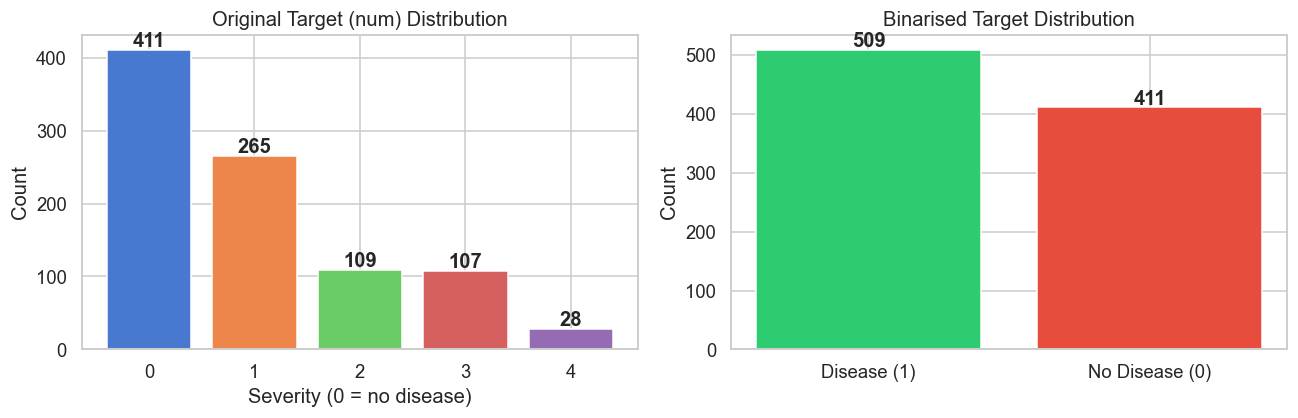

Class balance: 44.7% disease


In [10]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw multi-class
counts_raw = df["num"].value_counts().sort_index()
axes[0].bar(counts_raw.index.astype(str), counts_raw.values, color=sns.color_palette("muted"))
axes[0].set_title("Original Target (num) Distribution")
axes[0].set_xlabel("Severity (0 = no disease)")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts_raw.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Binarised
binary_counts = (df["num"] > 0).map({False: "No Disease (0)", True: "Disease (1)"}).value_counts()
axes[1].bar(binary_counts.index, binary_counts.values,
            color=["#2ecc71", "#e74c3c"])
axes[1].set_title("Binarised Target Distribution")
axes[1].set_ylabel("Count")
for i, v in enumerate(binary_counts.values):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../images/target_distribution.png", dpi=150)
plt.show()
print(f"Class balance: {binary_counts.values[1]/len(df)*100:.1f}% disease")

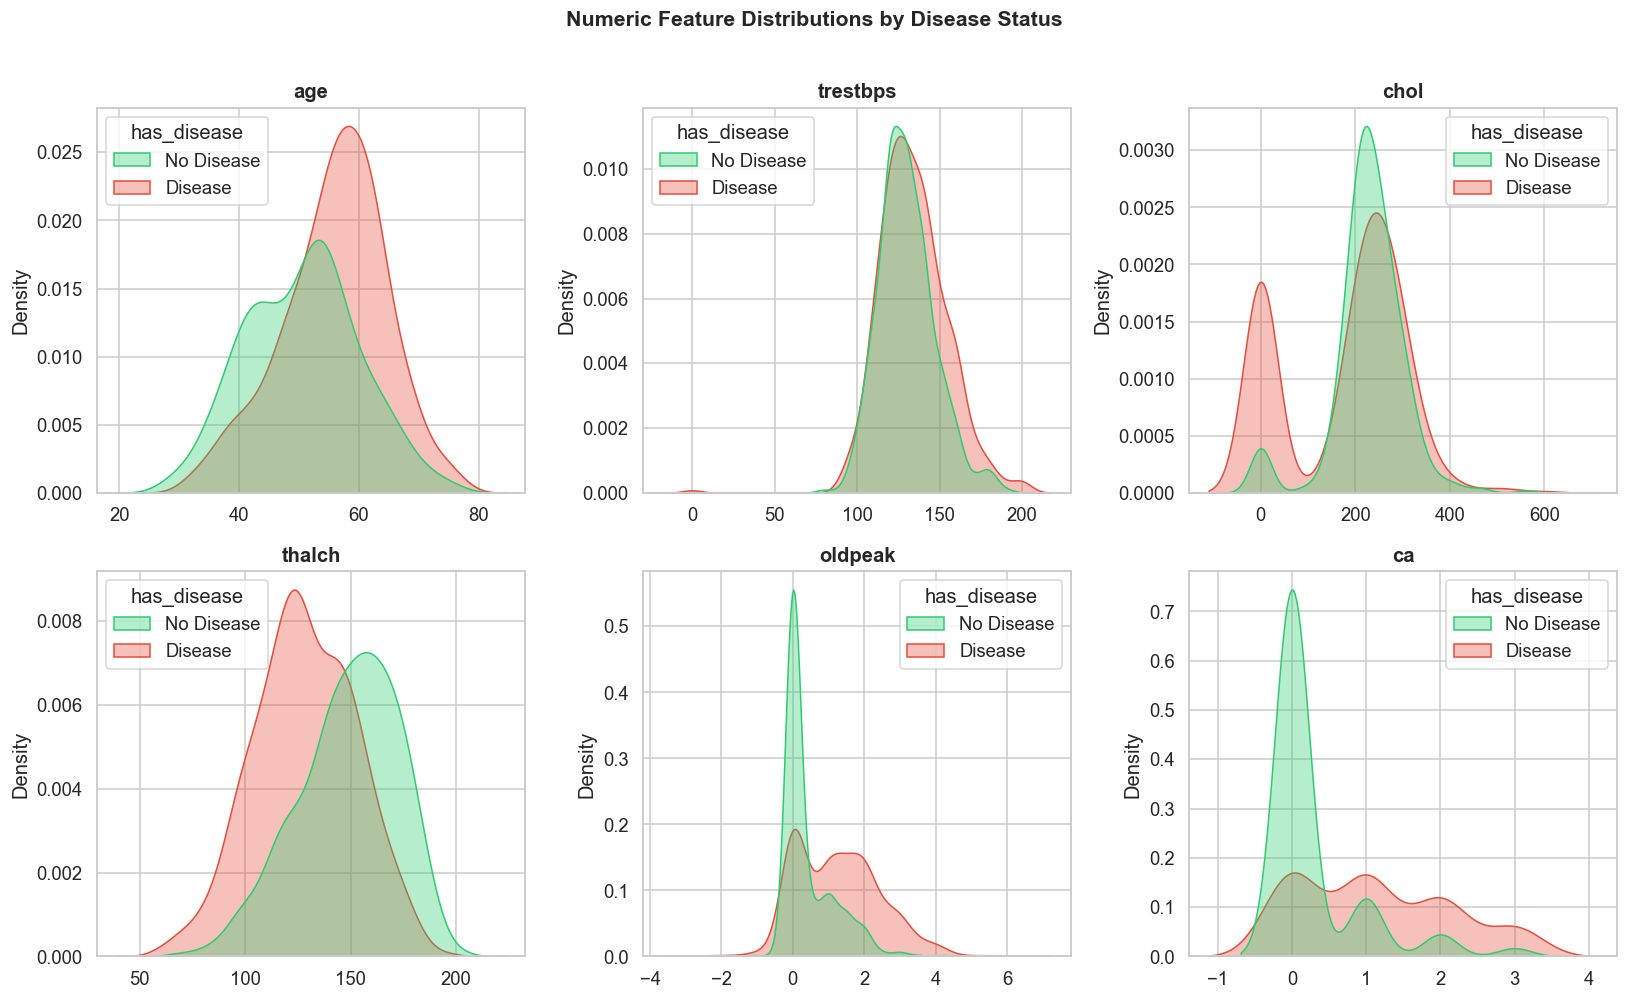

In [11]:

df_plot = df.copy()
df_plot["has_disease"] = (df_plot["num"] > 0).map({False: "No Disease", True: "Disease"})

numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sub = df_plot[["has_disease", col]].dropna()
    sns.kdeplot(data=sub, x=col, hue="has_disease",
                fill=True, alpha=0.35, ax=axes[i],
                palette={"No Disease": "#2ecc71", "Disease": "#e74c3c"})
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel("")

plt.suptitle("Numeric Feature Distributions by Disease Status", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../images/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Categorical features vs target

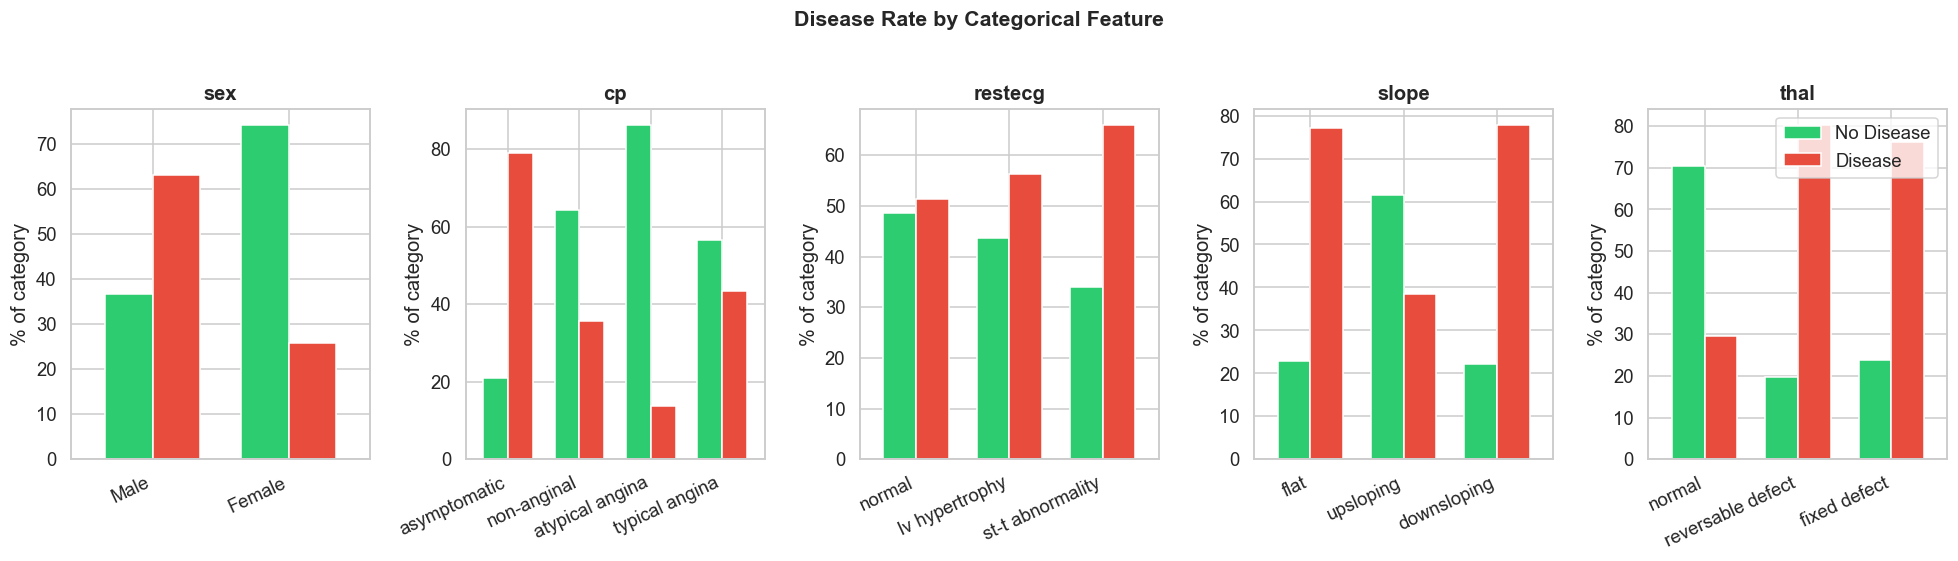

In [12]:

cat_cols = ["sex", "cp", "restecg", "slope", "thal"]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    sub = df_plot[[col, "has_disease"]].dropna()
    order = sub[col].value_counts().index
    ct = pd.crosstab(sub[col], sub["has_disease"])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct[["No Disease", "Disease"]].loc[order].plot(
        kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"],
        edgecolor="white", width=0.7
    )
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("% of category")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
    ax.legend().remove()

axes[-1].legend(title="", loc="upper right")
plt.suptitle("Disease Rate by Categorical Feature", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../images/categorical_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlation heatmap (numeric features after encoding)

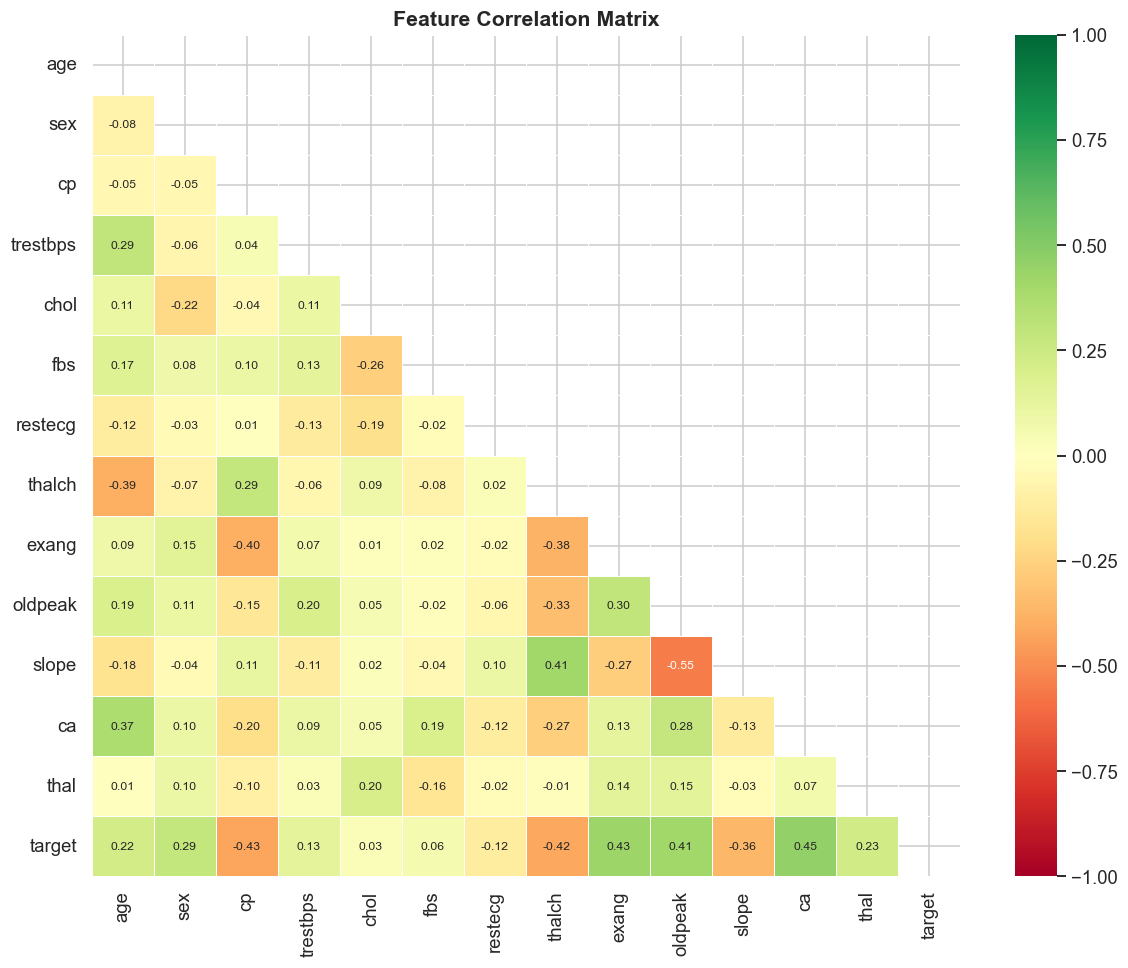

In [ ]:
df_enc = df.copy()
df_enc["target"] = (df_enc["num"] > 0).astype(int)
df_enc.drop(columns=["id", "dataset", "num"], inplace=True)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ["sex", "cp", "restecg", "slope", "thal", "fbs", "exang"]:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

df_enc = df_enc.apply(pd.to_numeric, errors="coerce").dropna()

corr = df_enc.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()